In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [115]:
df = pd.read_csv('oil_geopolitics_dataset_2010_2026.csv')
df

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,17-02-10,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0,0
1,18-02-10,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0,0
2,19-02-10,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0,0
3,22-02-10,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0,0
4,23-02-10,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4042,06-03-26,92.690002,90.900002,98.989998,29.490000,130.887665,0.085236,0.122084,85.410004,81.400002,...,65.419998,0.033662,0.029489,0.045250,0.034029,1.790001,none,none,0,0
4043,09-03-26,98.959999,94.769997,99.180000,25.500000,130.887665,0.067645,0.042574,92.690002,81.400002,...,65.209999,0.029502,0.031034,0.039384,0.034316,4.190002,blockade,Closure of Strait of Hormuz shipping lane,10,1
4044,10-03-26,87.800003,83.449997,98.830002,24.930000,130.887665,-0.112773,-0.119447,98.959999,85.410004,...,67.019997,0.068590,0.038639,0.077506,0.042092,4.350006,none,none,0,0
4045,11-03-26,91.980003,87.250000,99.230003,24.230000,130.887665,0.047608,0.045536,87.800003,92.690002,...,71.230003,0.066619,0.039074,0.076723,0.042435,4.730003,none,none,0,0


In [116]:
df.shape

(4047, 23)

In [117]:
df.head()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
0,17-02-10,76.269997,77.330002,80.379997,21.719999,80.725357,0.007796,0.004155,75.680000,73.050003,...,71.190002,0.014461,0.019679,0.016977,0.019280,-1.060005,none,none,0,0
1,18-02-10,77.779999,79.059998,80.400002,20.629999,80.725357,0.019798,0.022372,76.269997,72.900002,...,71.889999,0.014387,0.020019,0.017366,0.019756,-1.279999,none,none,0,0
2,19-02-10,78.190002,79.809998,80.639999,20.020000,80.725357,0.005271,0.009486,77.779999,75.680000,...,73.750000,0.013342,0.019796,0.016553,0.019559,-1.619995,none,none,0,0
3,22-02-10,78.610001,80.160004,80.510002,19.940001,80.725357,0.005372,0.004385,78.190002,76.269997,...,74.519997,0.013366,0.019823,0.016772,0.019561,-1.550003,none,none,0,0
4,23-02-10,77.250000,78.860001,80.849998,21.370001,80.725357,-0.017301,-0.016218,78.610001,77.779999,...,75.279999,0.017334,0.020045,0.019608,0.019756,-1.610001,none,none,0,0


In [118]:
df.tail()

,date,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,...,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_type,event_description,event_severity,event_flag
4042,06-03-26,92.690002,90.900002,98.989998,29.49,130.887665,0.085236,0.122084,85.410004,81.400002,...,65.419998,0.033662,0.029489,0.045250,0.034029,1.790001,none,none,0,0
4043,09-03-26,98.959999,94.769997,99.180000,25.50,130.887665,0.067645,0.042574,92.690002,81.400002,...,65.209999,0.029502,0.031034,0.039384,0.034316,4.190002,blockade,Closure of Strait of Hormuz shipping lane,10,1
4044,10-03-26,87.800003,83.449997,98.830002,24.93,130.887665,-0.112773,-0.119447,98.959999,85.410004,...,67.019997,0.068590,0.038639,0.077506,0.042092,4.350006,none,none,0,0
4045,11-03-26,91.980003,87.250000,99.230003,24.23,130.887665,0.047608,0.045536,87.800003,92.690002,...,71.230003,0.066619,0.039074,0.076723,0.042435,4.730003,none,none,0,0
4046,12-03-26,95.760002,94.309998,99.463997,24.23,130.887665,0.041096,0.080917,91.980003,98.959999,...,74.559998,0.066346,0.039457,0.078875,0.044257,1.450005,none,none,0,0


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4047 entries, 0 to 4046
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4047 non-null   object 
 1   brent_price           4047 non-null   float64
 2   wti_price             4047 non-null   float64
 3   dxy_index             4047 non-null   float64
 4   vix                   4047 non-null   float64
 5   gpr_index             4047 non-null   float64
 6   brent_return          4047 non-null   float64
 7   wti_return            4047 non-null   float64
 8   brent_lag_1           4047 non-null   float64
 9   brent_lag_3           4047 non-null   float64
 10  brent_lag_7           4047 non-null   float64
 11  wti_lag_1             4047 non-null   float64
 12  wti_lag_3             4047 non-null   float64
 13  wti_lag_7             4047 non-null   float64
 14  brent_volatility_7d   4047 non-null   float64
 15  brent_volatility_30d 

In [120]:
df.describe()

,brent_price,wti_price,dxy_index,vix,gpr_index,brent_return,wti_return,brent_lag_1,brent_lag_3,brent_lag_7,wti_lag_1,wti_lag_3,wti_lag_7,brent_volatility_7d,brent_volatility_30d,wti_volatility_7d,wti_volatility_30d,brent_wti_spread,event_severity,event_flag
count,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000,4047.000000
mean,77.623944,71.417546,92.909040,18.393249,102.596421,0.000311,-0.000541,77.618982,77.610623,77.592315,71.413272,71.408011,71.395659,0.018633,0.019633,0.022485,0.025251,6.206397,0.049666,0.006177
std,23.529261,20.777323,9.285512,6.853769,31.559190,0.022377,0.058092,23.527553,23.526150,23.523086,20.774392,20.772170,20.766139,0.012174,0.010410,0.051673,0.052097,5.349998,0.634916,0.078363
min,19.330000,-37.630001,72.930000,9.140000,58.420769,-0.244036,-3.059661,19.330000,19.330000,19.330000,-37.630001,-37.630001,-37.630001,0.002542,0.005798,0.002151,0.007033,-2.680000,0.000000,0.000000
25%,60.785000,54.340000,82.735001,13.775000,81.389641,-0.009710,-0.011472,60.785000,60.785000,60.785000,54.340000,54.340000,54.340000,0.010933,0.013351,0.012497,0.014673,2.899999,0.000000,0.000000
50%,75.169998,71.120003,95.309998,16.650000,93.521255,0.000539,0.000923,75.169998,75.169998,75.129997,71.120003,71.120003,71.120003,0.015846,0.017360,0.017089,0.018465,4.430000,0.000000,0.000000
75%,98.155003,88.180000,99.180000,21.010000,116.716286,0.010995,0.012397,98.155003,98.155003,98.135002,88.160000,88.160000,88.139999,0.022550,0.023049,0.024280,0.025354,7.549997,0.000000,0.000000
max,127.980003,123.699997,114.110001,82.690002,318.954926,0.210186,0.376623,127.980003,127.980003,127.980003,123.699997,123.699997,123.699997,0.114916,0.088615,1.230410,0.620497,63.200001,10.000000,1.000000


In [121]:
df.dtypes

date                     object
brent_price             float64
wti_price               float64
dxy_index               float64
vix                     float64
gpr_index               float64
brent_return            float64
wti_return              float64
brent_lag_1             float64
brent_lag_3             float64
brent_lag_7             float64
wti_lag_1               float64
wti_lag_3               float64
wti_lag_7               float64
brent_volatility_7d     float64
brent_volatility_30d    float64
wti_volatility_7d       float64
wti_volatility_30d      float64
brent_wti_spread        float64
event_type               object
event_description        object
event_severity            int64
event_flag                int64
dtype: object

In [122]:
df.isnull().sum()

date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
df.drop_duplicates(inplace=True)

In [145]:
df['date'] = pd.to_datetime(df['date'])

In [126]:
df = df.sort_values('date') 

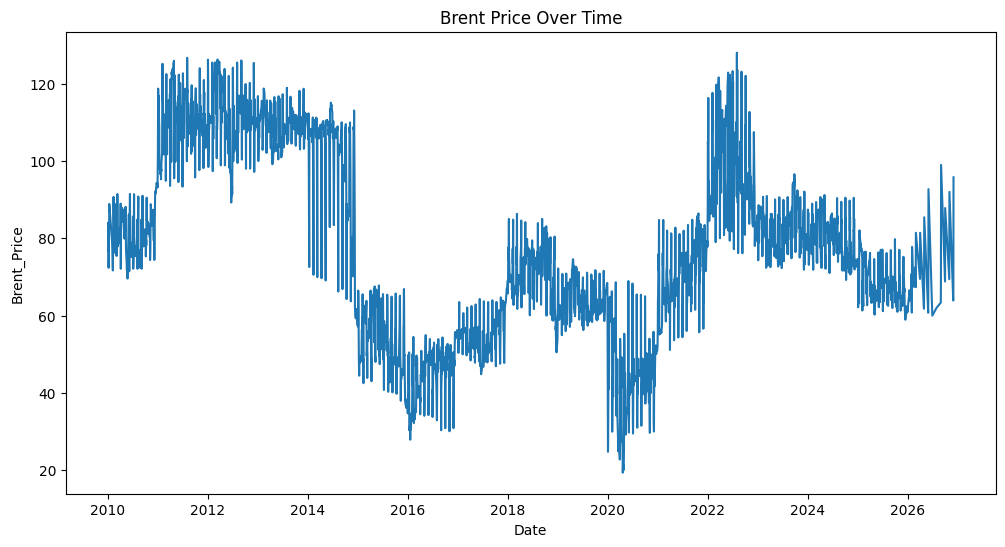

In [158]:
plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='brent_price', data=df)
plt.title('Brent Price Over Time')
plt.xlabel('Date')
plt.ylabel('Brent_Price')
plt.show()

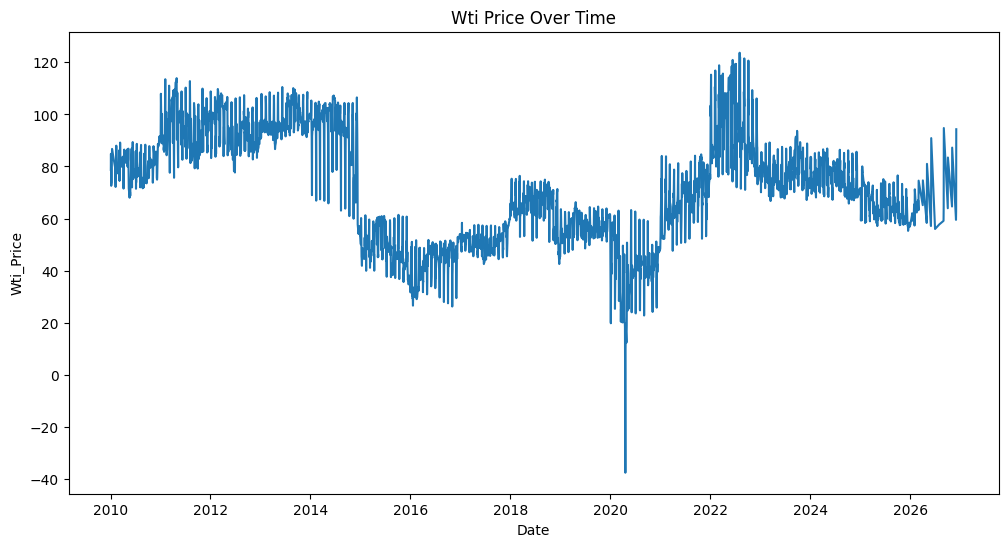

In [128]:
plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='wti_price', data=df)
plt.title('Wti Price Over Time')
plt.xlabel('Date')
plt.ylabel('Wti_Price')
plt.show()

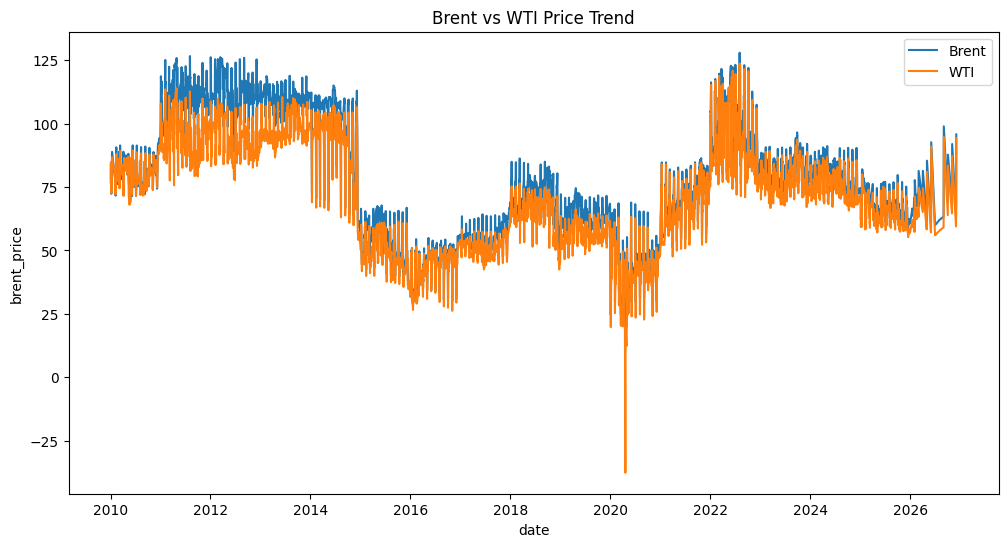

In [159]:
plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='brent_price', data=df, label='Brent')
sns.lineplot(x='date', y='wti_price', data=df, label='WTI')
plt.title("Brent vs WTI Price Trend")
plt.show()

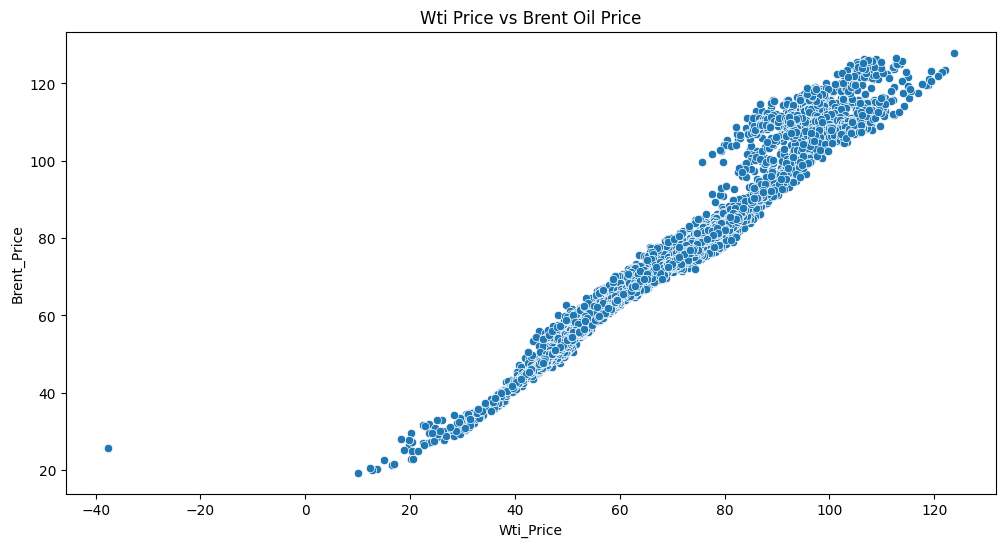

In [129]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='wti_price', y='brent_price', data=df)
plt.title('Wti Price vs Brent Oil Price')
plt.xlabel('Wti_Price')
plt.ylabel('Brent_Price')
plt.show()

Text(0.5, 1.0, 'Brent_Pice & WTI_Price')

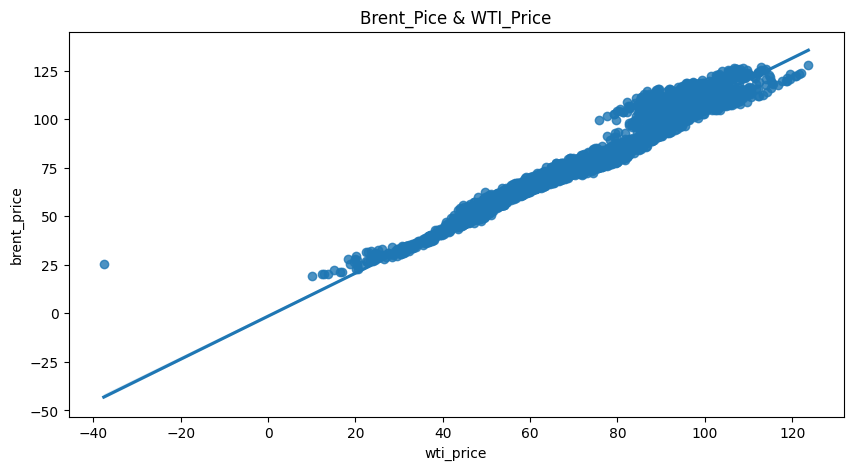

In [130]:
plt.figure(figsize=(10,5))
sns.regplot(x='wti_price', y='brent_price', data=df)
plt.title("Brent_Pice & WTI_Price")


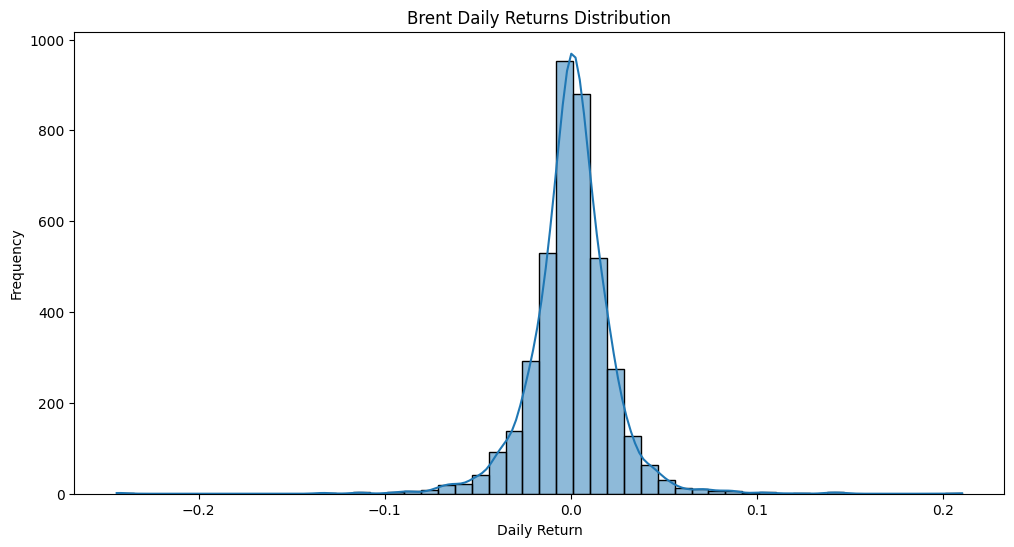

In [134]:
plt.figure(figsize=(12,6))
sns.histplot(df['brent_return'], bins=50, kde=True)
plt.title('Brent Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

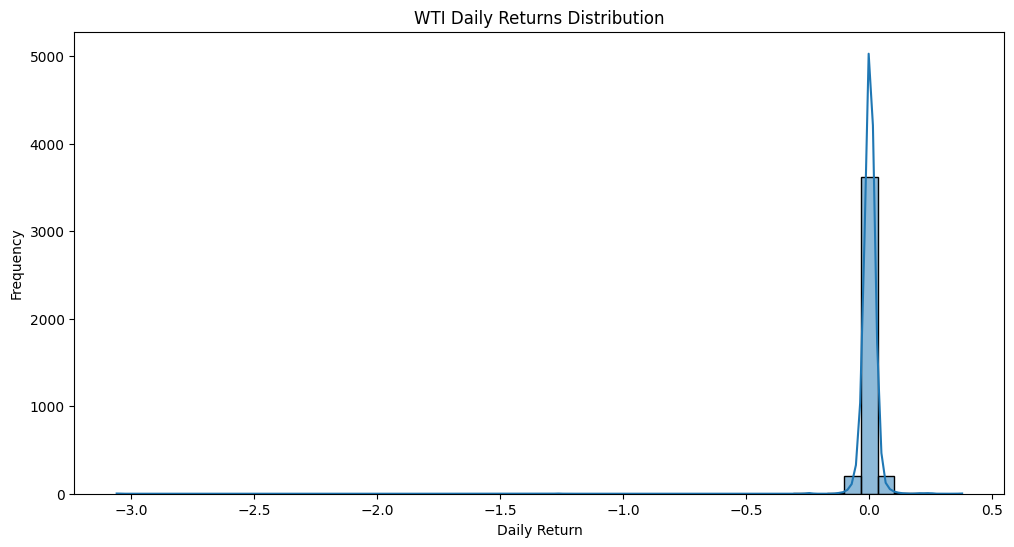

In [135]:
plt.figure(figsize=(12,6))
sns.histplot(df['wti_return'], bins=50, kde=True)
plt.title('WTI Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

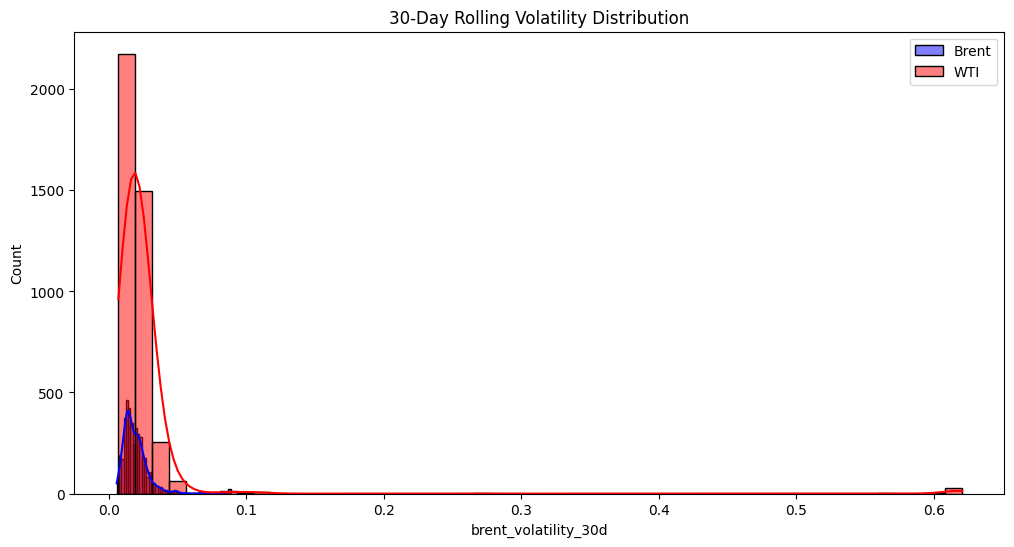

In [136]:
plt.figure(figsize=(12,6))
sns.histplot(df['brent_volatility_30d'], bins=50, color='blue', label='Brent', kde=True)
sns.histplot(df['wti_volatility_30d'], bins=50, color='red', label='WTI', kde=True)
plt.legend()
plt.title('30-Day Rolling Volatility Distribution')
plt.show()

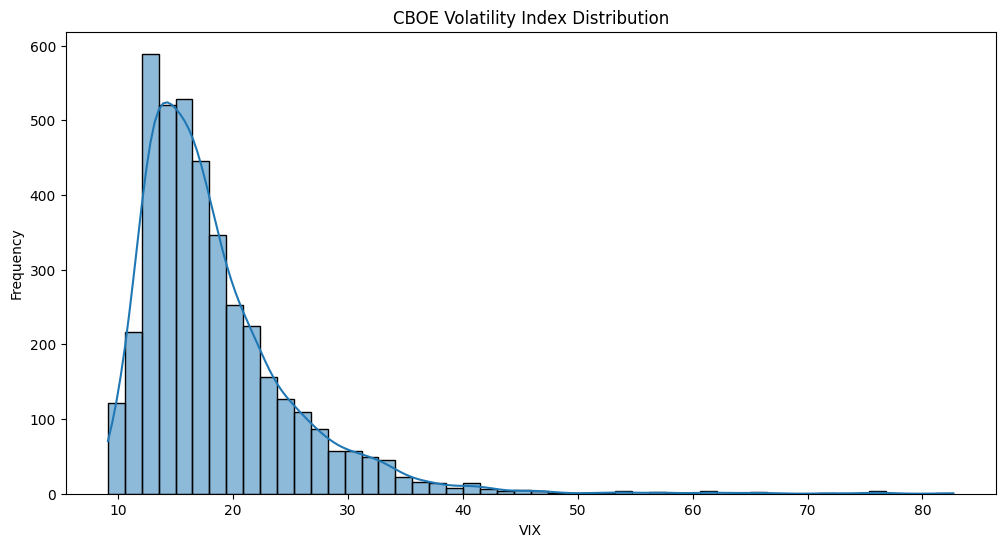

In [162]:
plt.figure(figsize=(12,6))
sns.histplot(df['vix'],bins=50, kde=True)
plt.title("CBOE Volatility Index Distribution")
plt.xlabel("VIX")
plt.ylabel("Frequency")
plt.show()

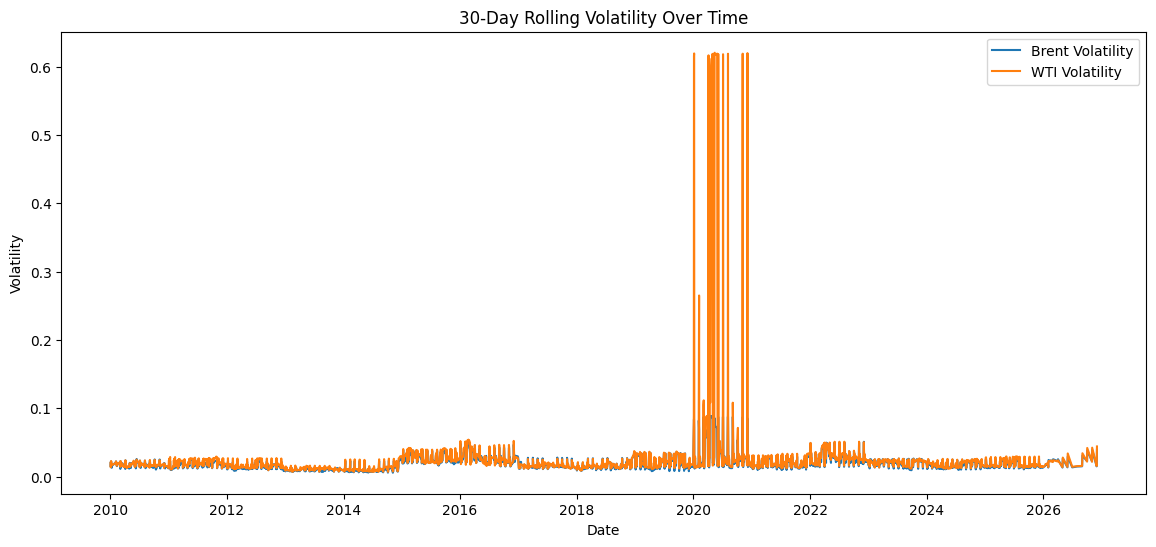

In [138]:
plt.figure(figsize=(14,6))

sns.lineplot(x='date', y='brent_volatility_30d', data=df, label='Brent Volatility')
sns.lineplot(x='date', y='wti_volatility_30d', data=df, label='WTI Volatility')

plt.title('30-Day Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

Text(0.5, 1.0, 'Brent vs VIX')

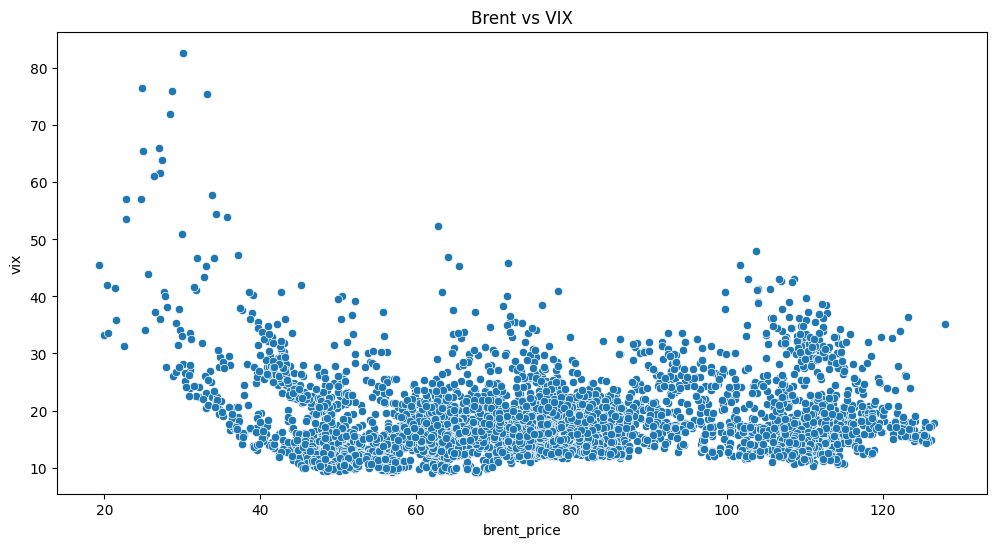

In [139]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='brent_price',y='vix',data=df)
plt.title("Brent vs VIX")

Text(0.5, 1.0, 'WTI vs VIX')

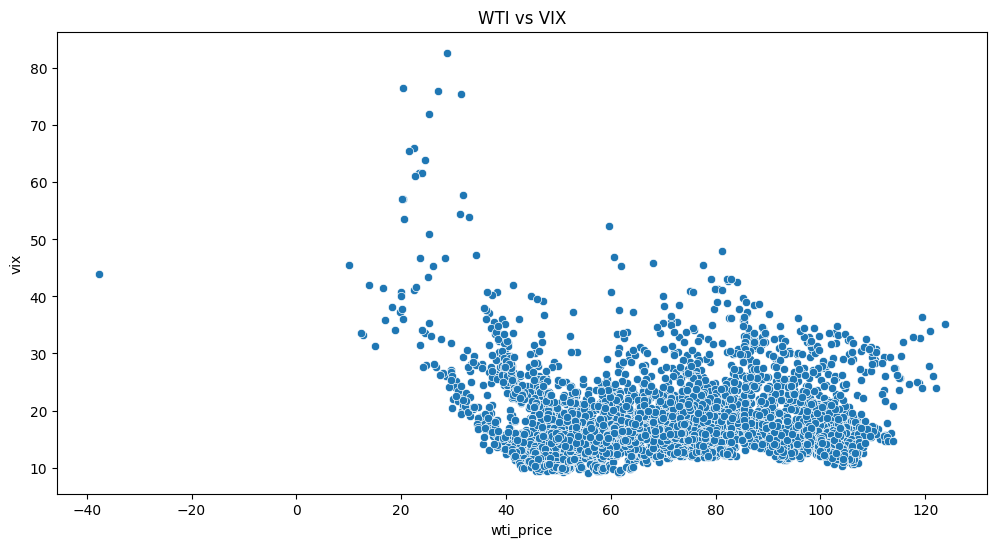

In [160]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='wti_price',y='vix',data=df)
plt.title("WTI vs VIX")

Text(0.5, 1.0, 'Brent vs DXY Index')

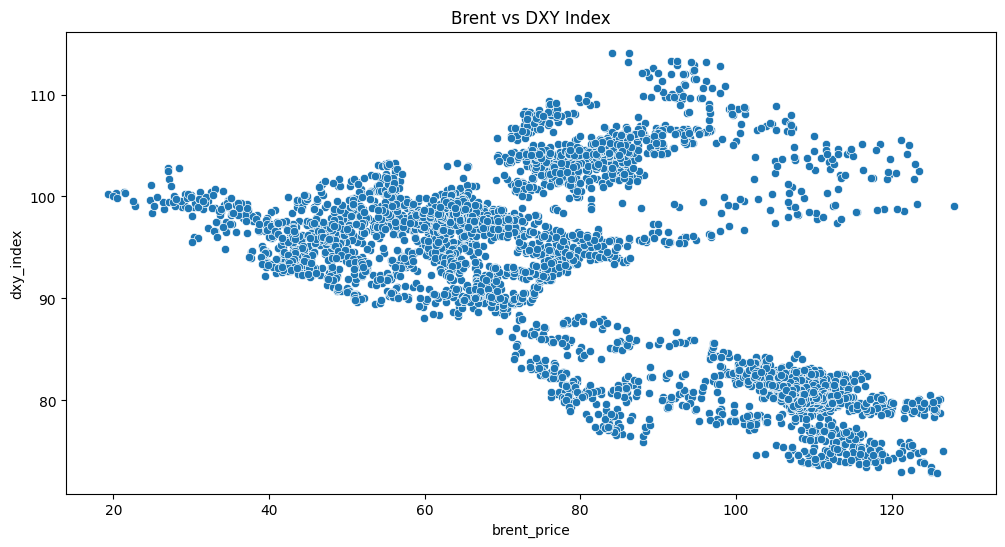

In [140]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='brent_price',y='dxy_index',data=df)
plt.title("Brent vs DXY Index")

Text(0.5, 1.0, 'WTI vs DXY Index')

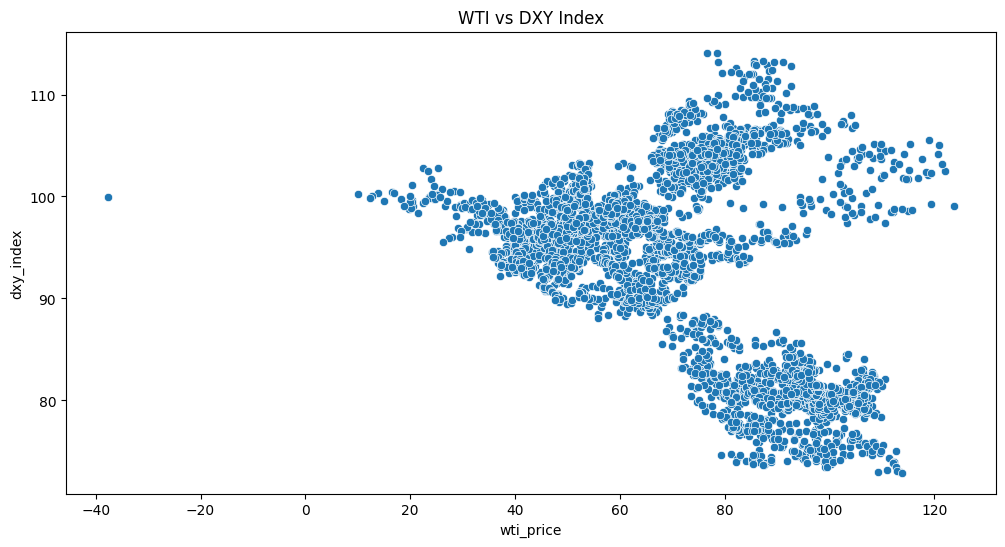

In [161]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='wti_price',y='dxy_index',data=df)
plt.title("WTI vs DXY Index")

Text(0.5, 1.0, 'correlation HeatMap')

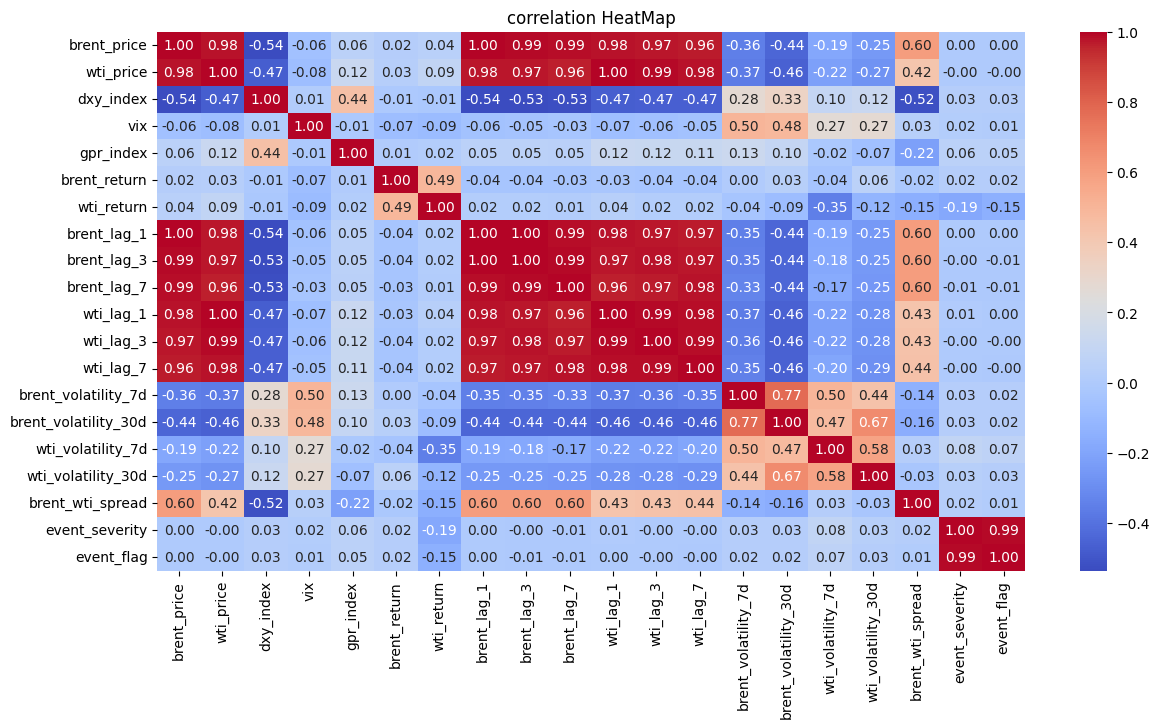

In [141]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,7))
sns.heatmap(corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f")
plt.title("correlation HeatMap")

In [ ]:
sns.boxplot(data=df[['brent_price','wti_price','vix','dxy_index']])

Text(0.5, 1.0, 'oil price during geopolitical events vs normal periods.')

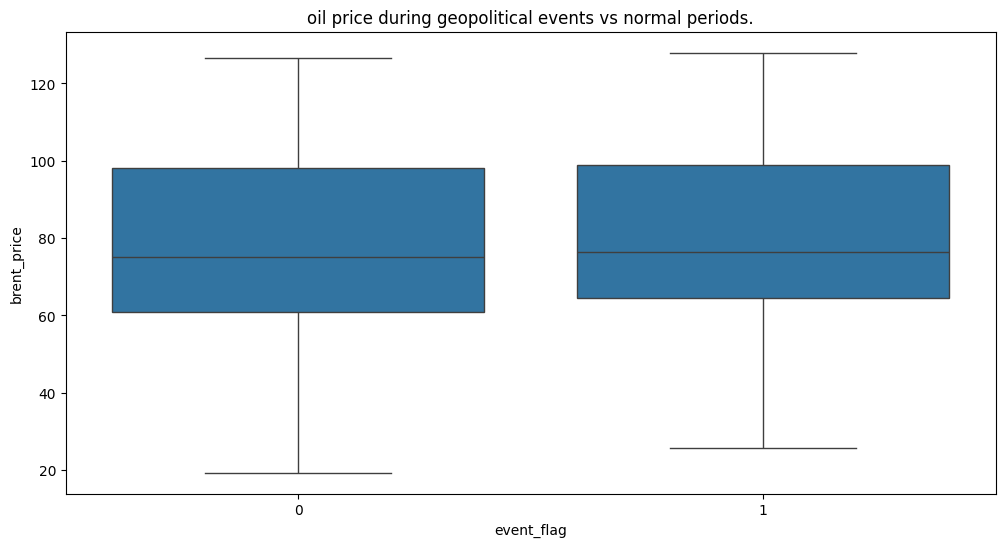

In [150]:
plt.figure(figsize=(12,6))
sns.boxplot(x='event_flag', y='brent_price', data=df)
plt.title("oil price during geopolitical events vs normal periods.")

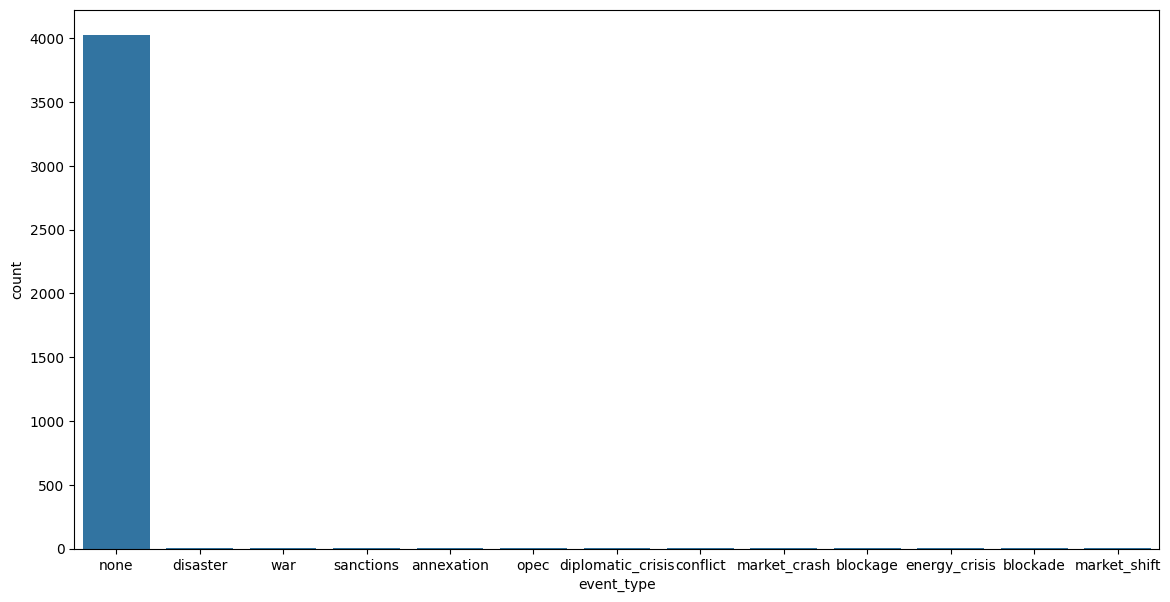

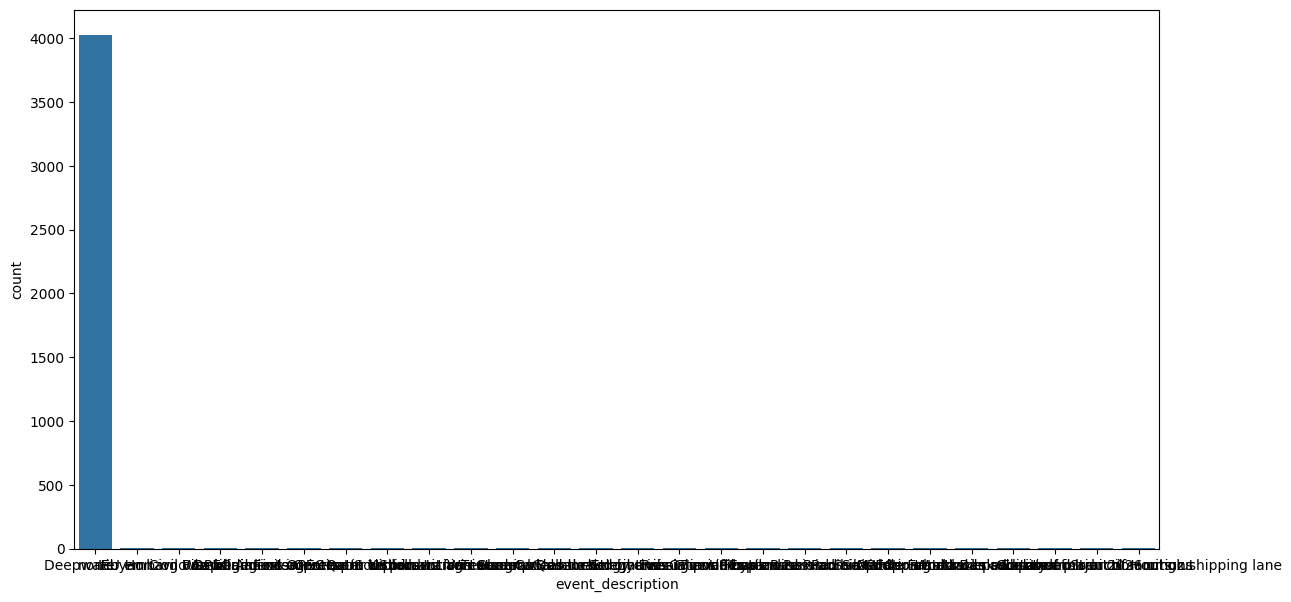

In [156]:
for col in df:
    if df[col].dtype == 'O':
        plt.figure(figsize=(14,7))
        sns.countplot(x=col,data=df)
        plt.show()